Molecule          Type Transition  n  Frequency_cm1  Shift_cm1   wexe  Dipole_D  Raw_Intensity
      N2   Homonuclear        0→1  1        2329.92      28.65 14.324     0.000       0.000000
      N2   Homonuclear        0→2  2        4631.20      85.94 14.324     0.000       0.000000
      N2   Homonuclear        0→3  3        6903.82     171.89 14.324     0.000       0.000000
      N2   Homonuclear        0→4  4        9147.80     286.48 14.324     0.000       0.000000
      N2   Homonuclear        0→5  5       11363.13     429.72 14.324     0.000       0.000000
      O2   Homonuclear        0→1  1        1556.23      23.96 11.980     0.000       0.000000
      O2   Homonuclear        0→2  2        3088.50      71.88 11.980     0.000       0.000000
      O2   Homonuclear        0→3  3        4596.81     143.76 11.980     0.000       0.000000
      O2   Homonuclear        0→4  4        6081.16     239.60 11.980     0.000       0.000000
      O2   Homonuclear        0→5  5        7541.5

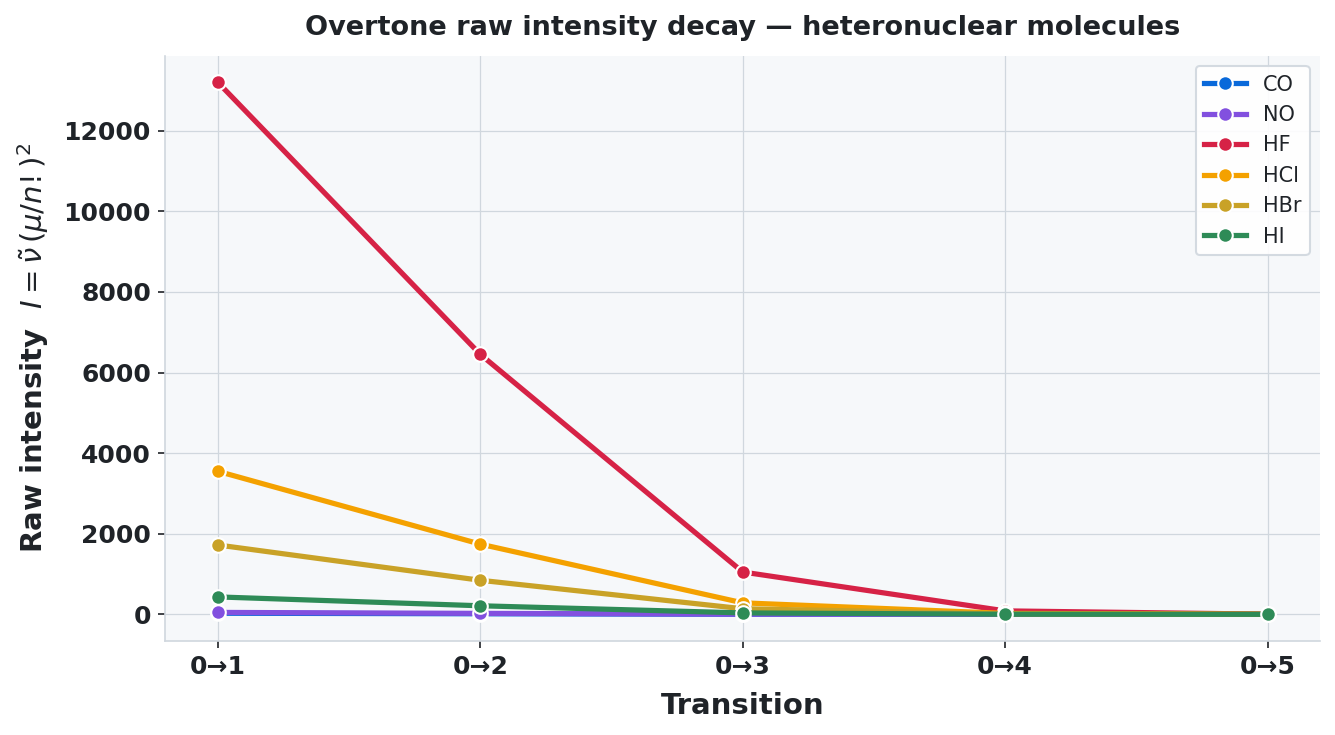

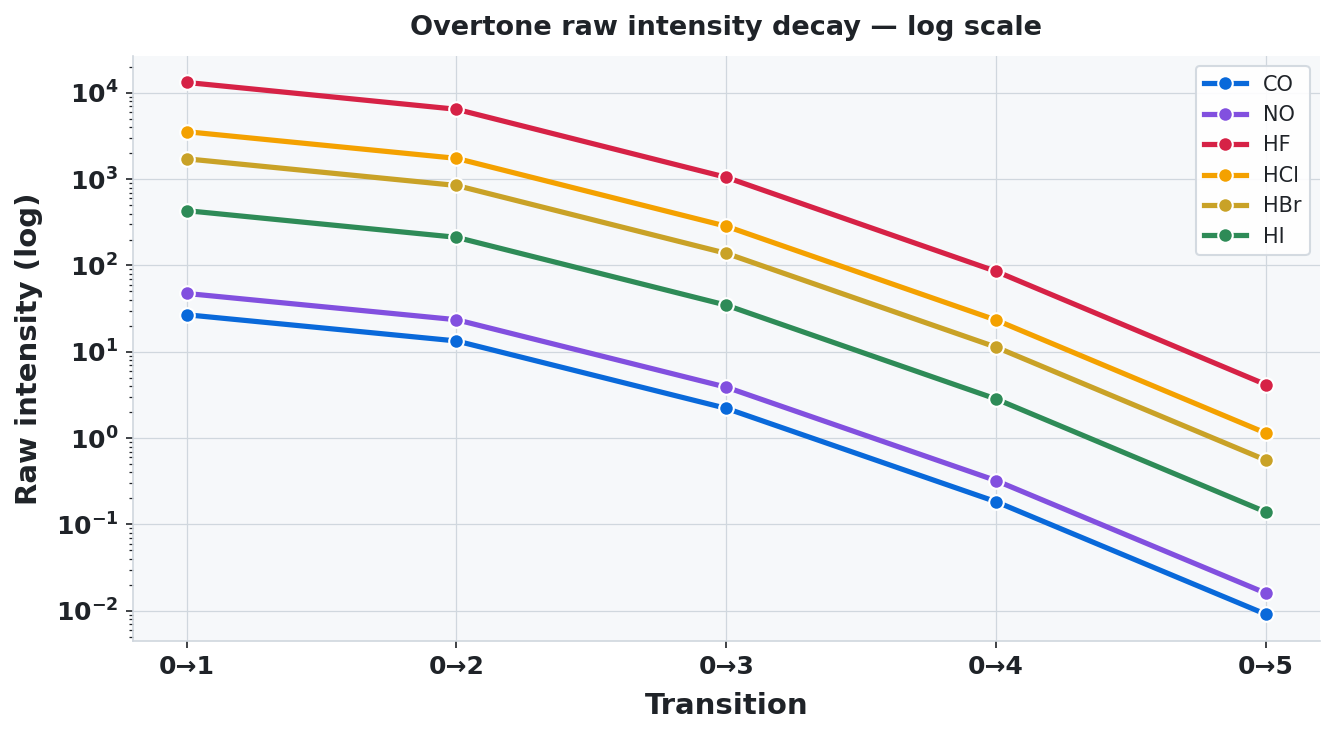

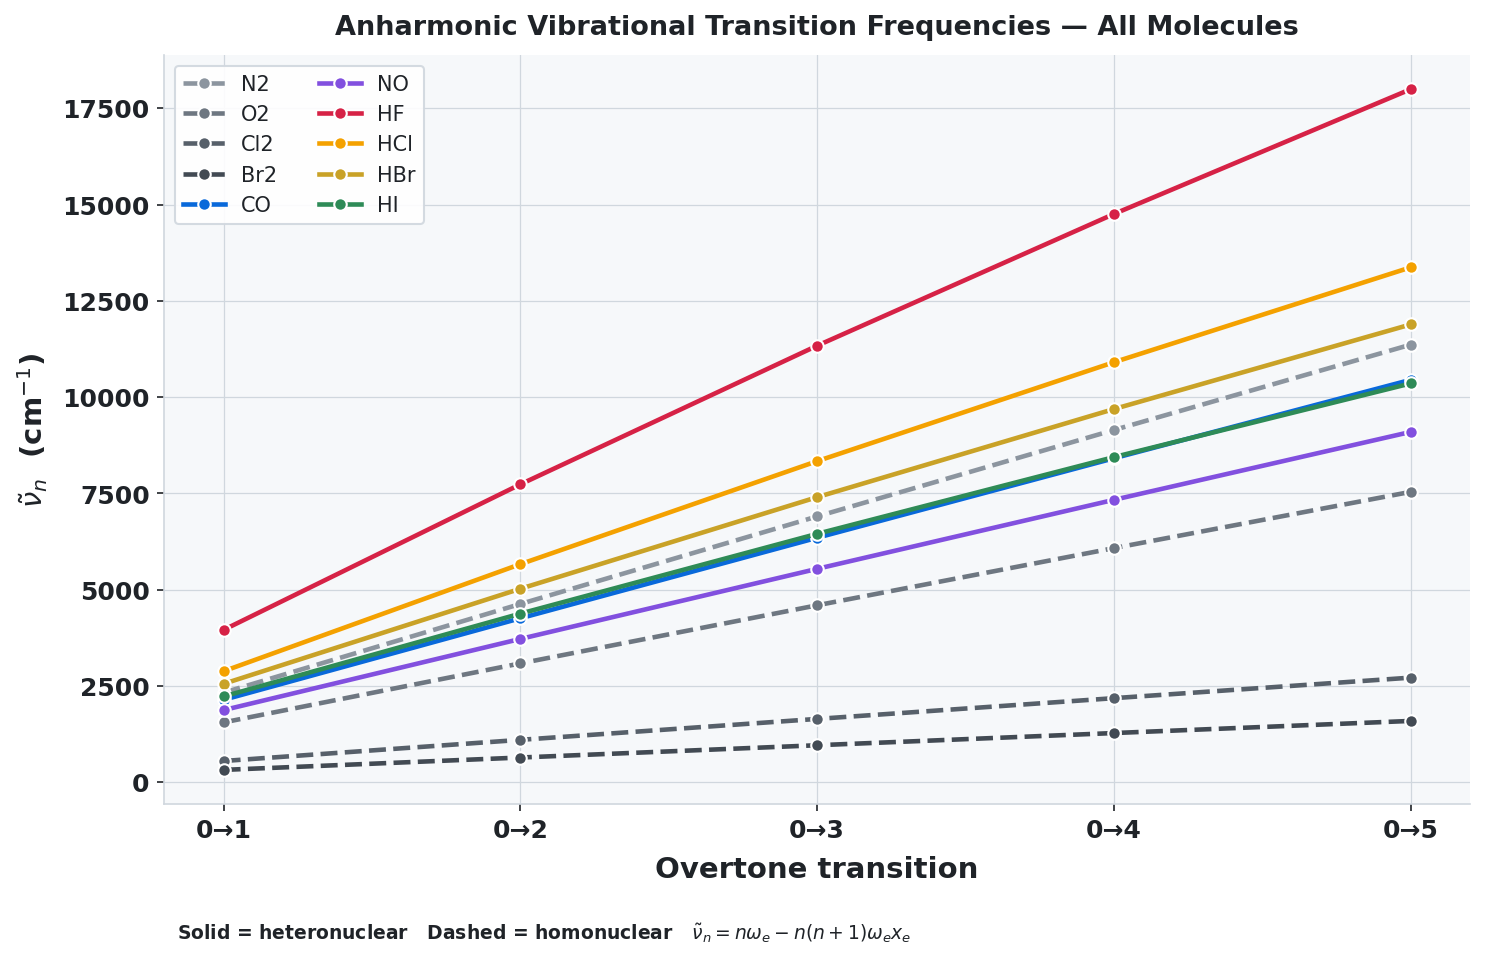

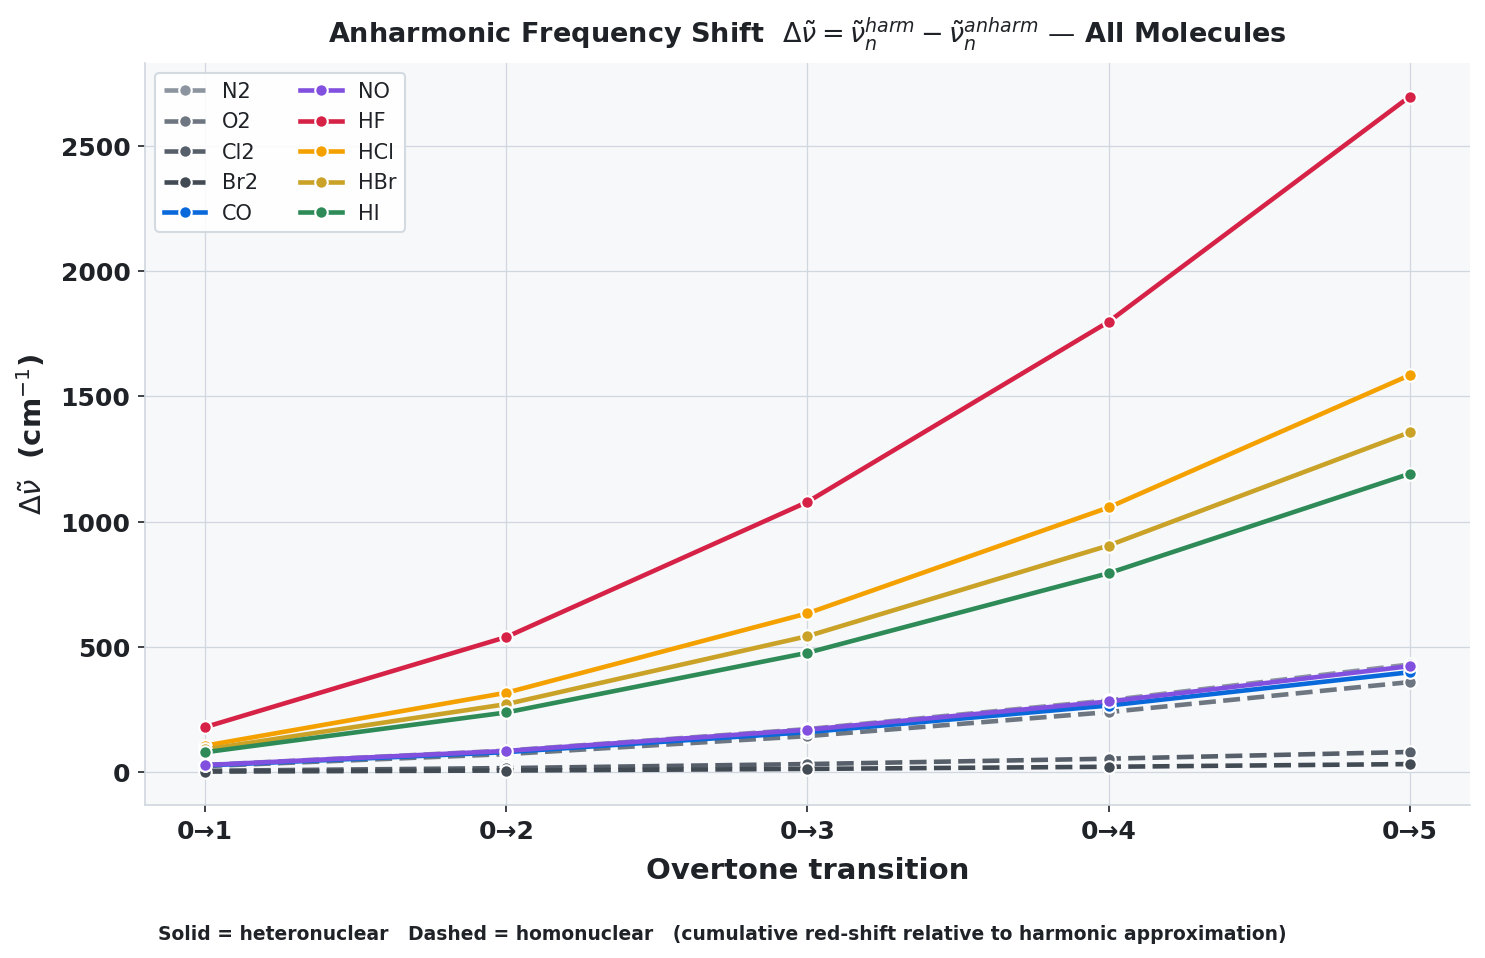

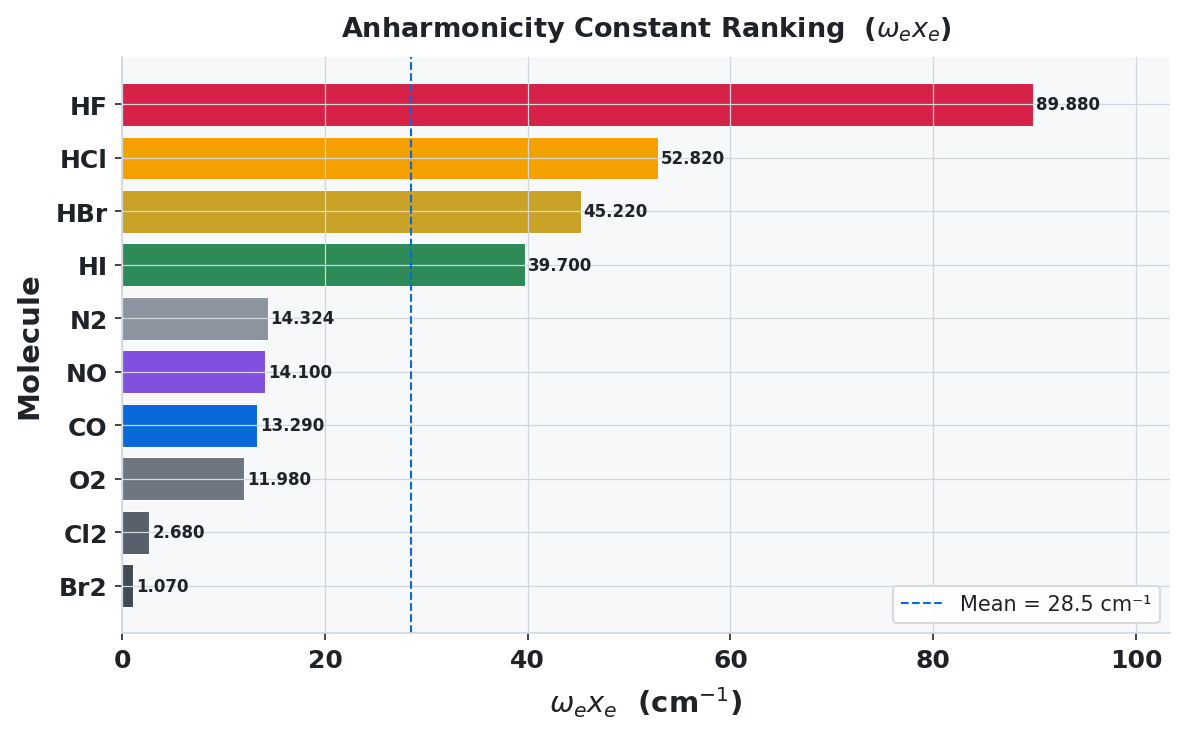

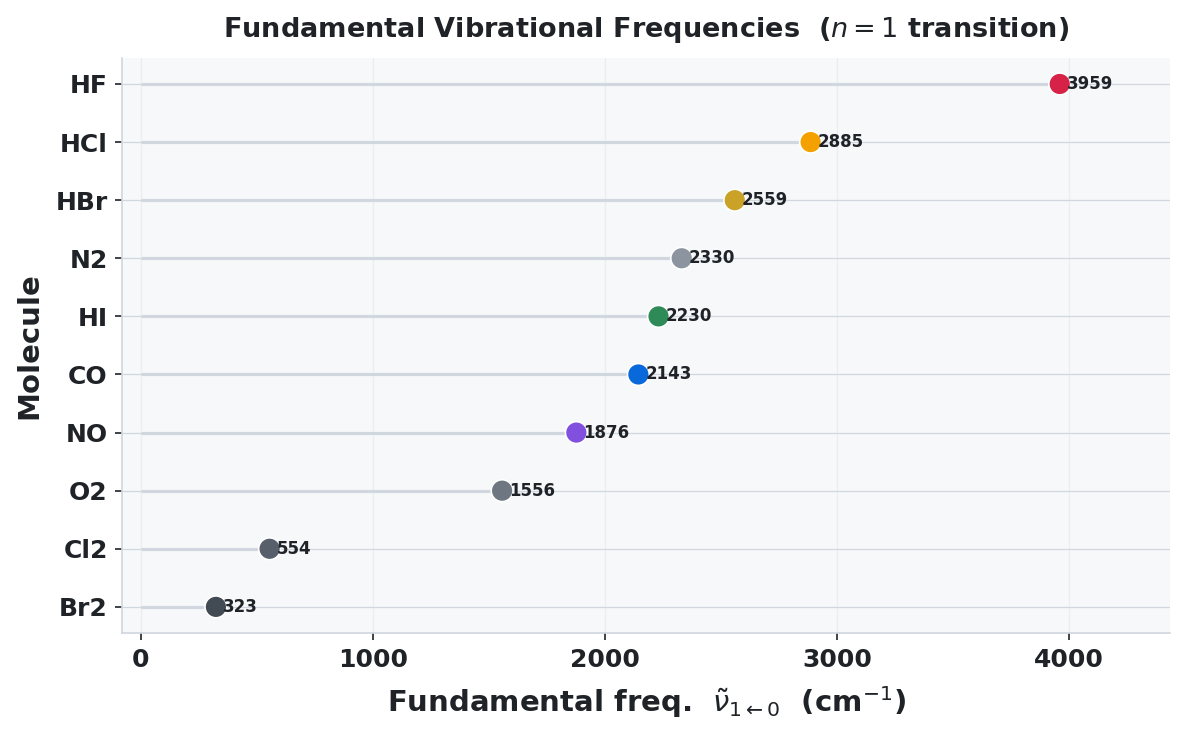

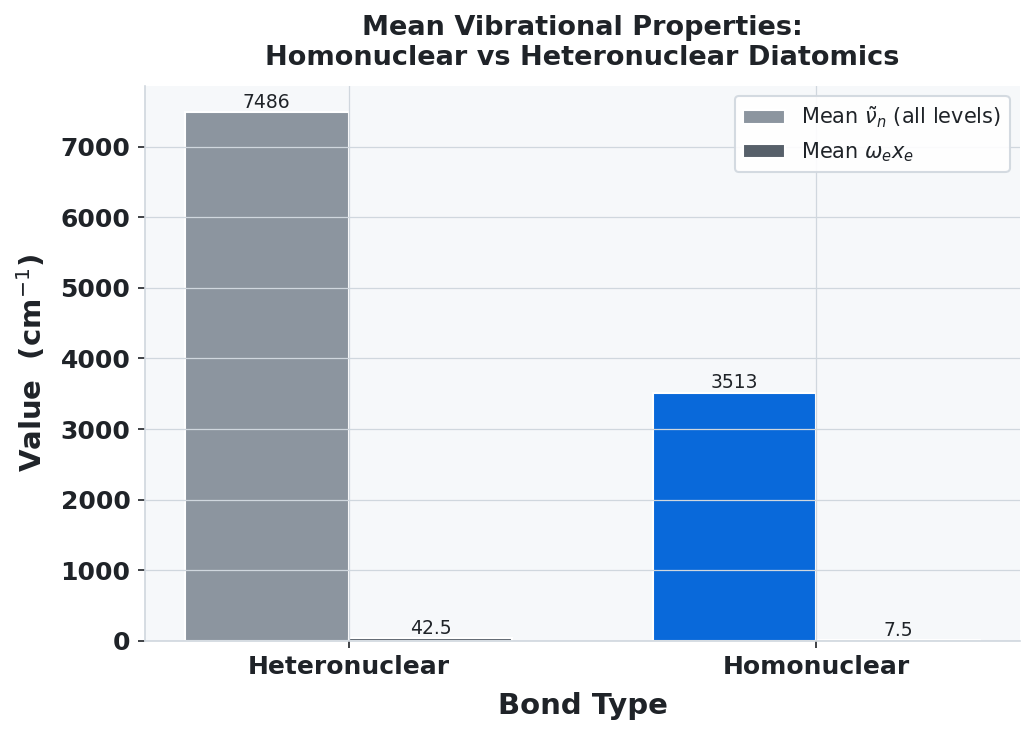

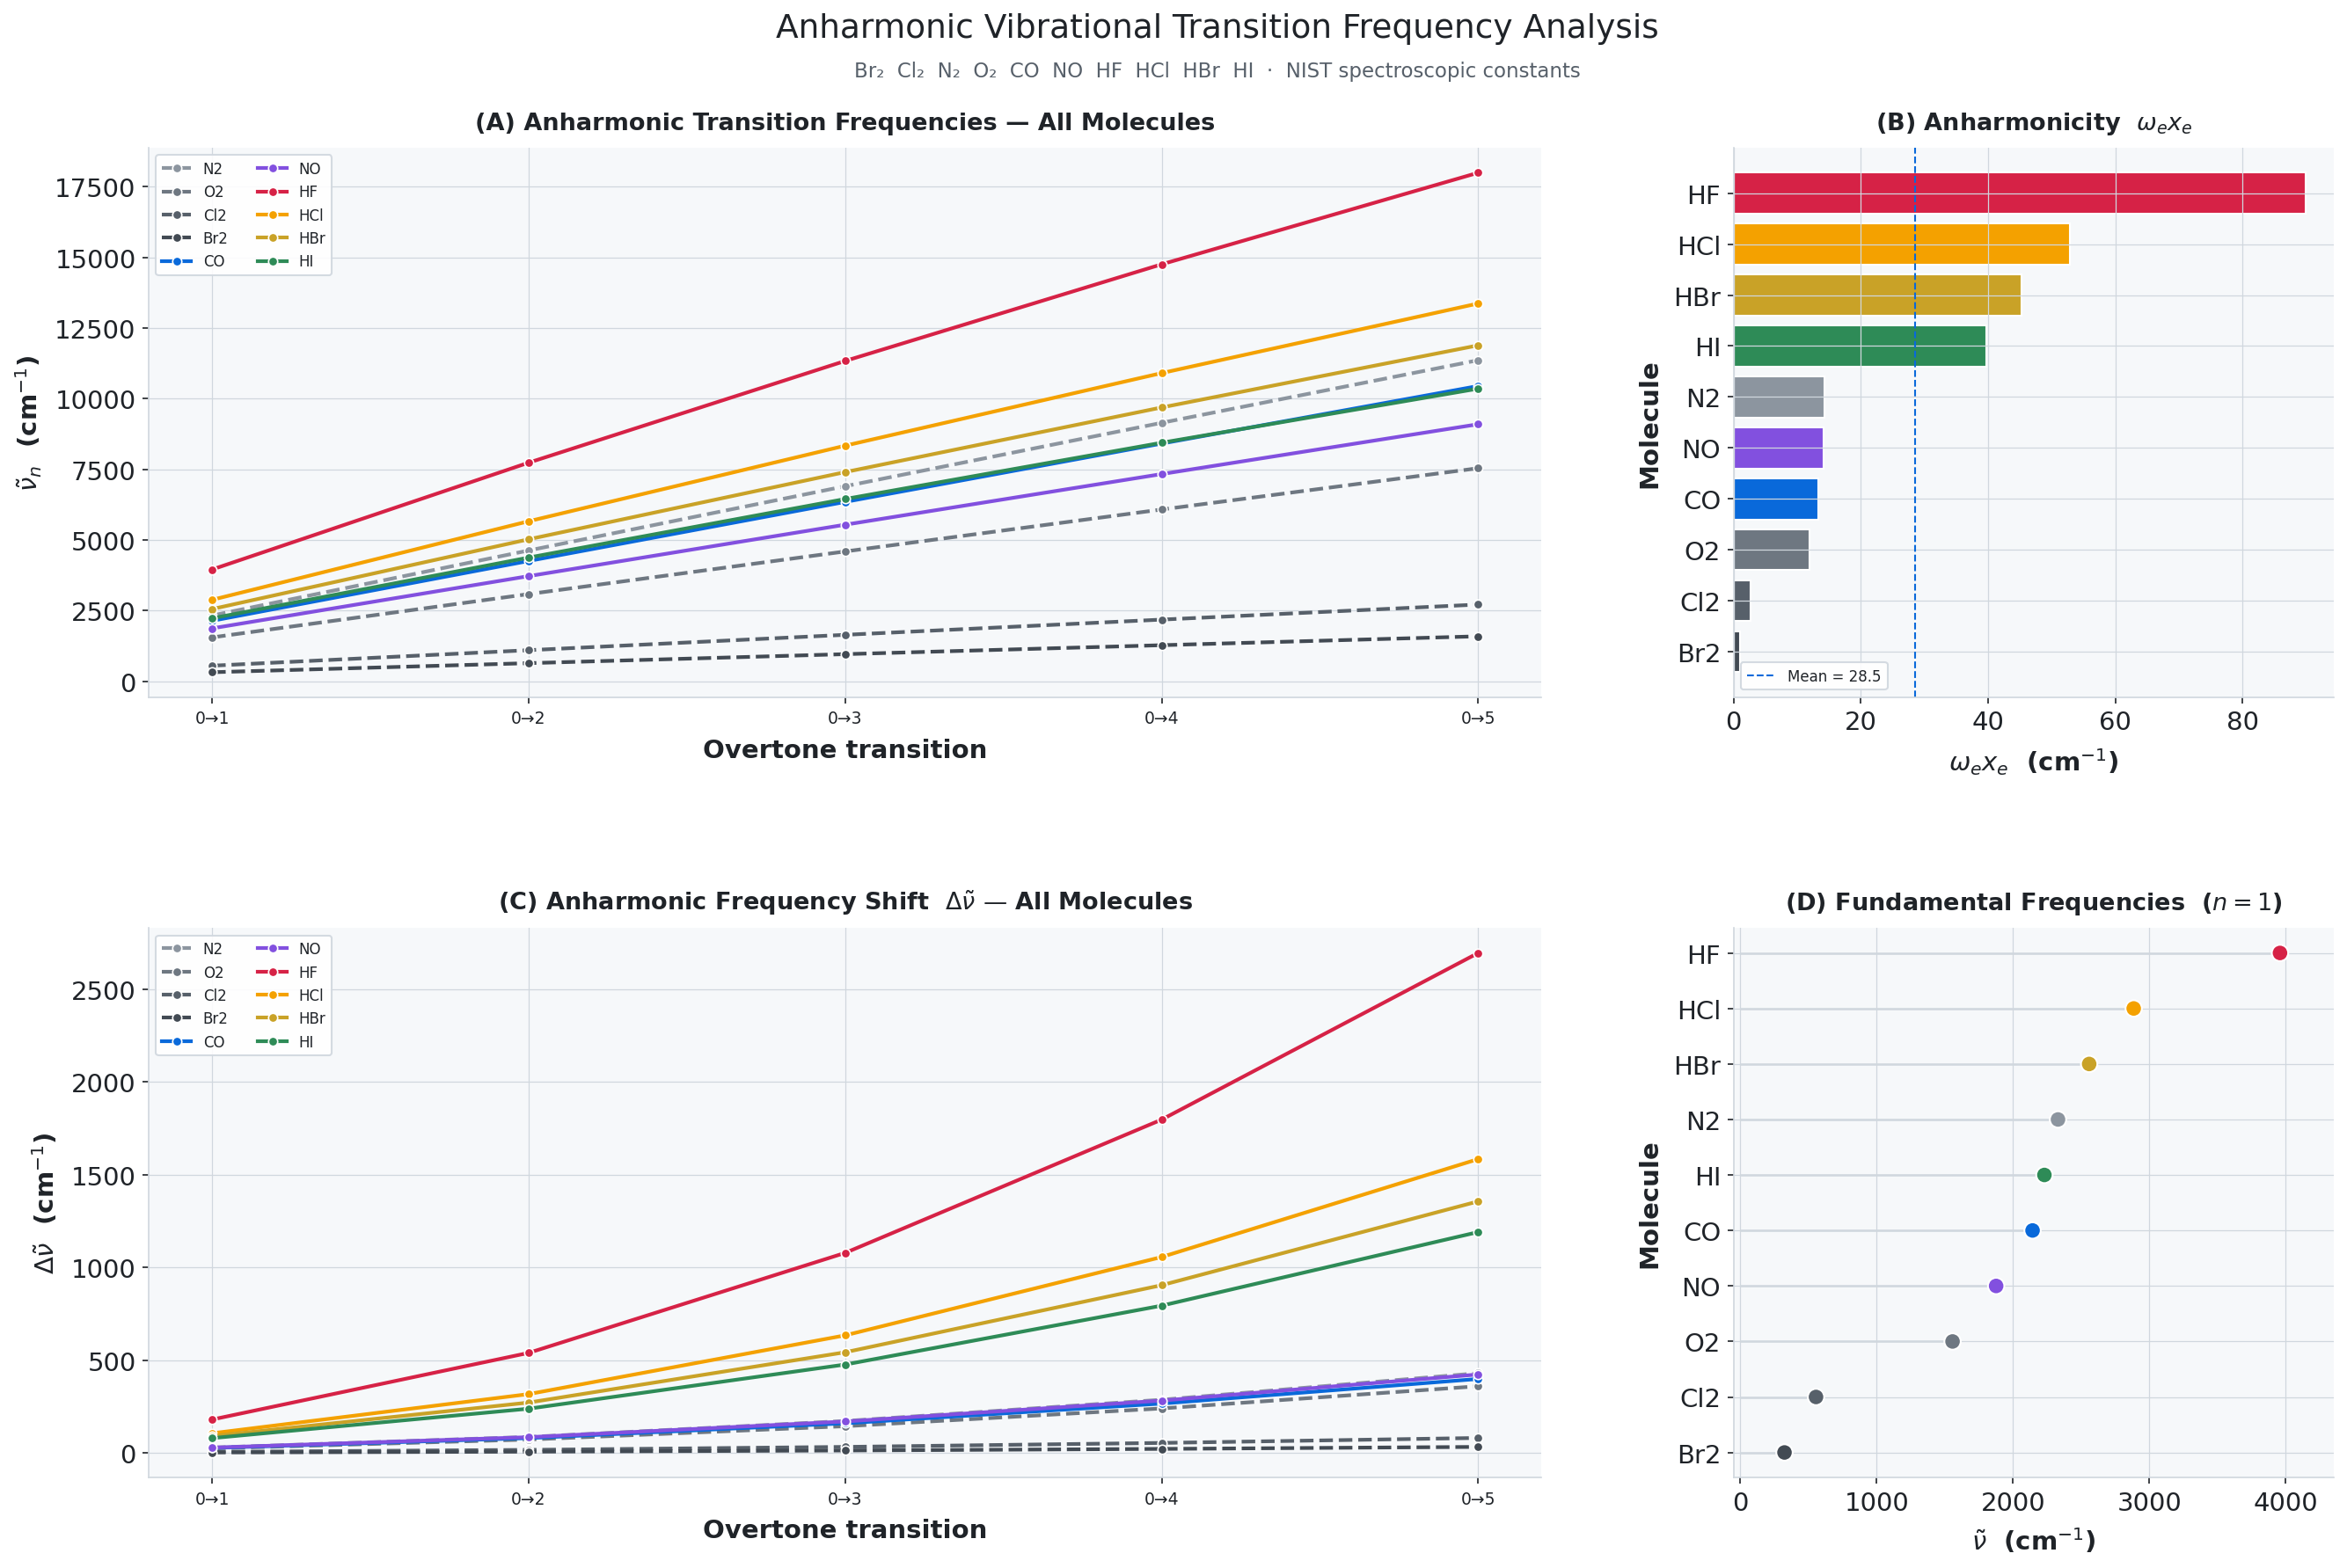


All figures saved.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import LogFormatter
import math

# ==========================================================
# GLOBAL STYLE (light theme)  — defined ONCE
# ==========================================================

BG       = "#FFFFFF"
PANEL_BG = "#F6F8FA"
GRID_CLR = "#D0D7DE"
TEXT_PRI = "#1F2328"
TEXT_SEC = "#57606A"
ACCENT   = "#0969DA"

MOL_COLORS = {
   "HF":  "#D62246",
   "HCl": "#F4A100",
   "HBr": "#C9A227",
   "HI":  "#2E8B57",
   "CO":  "#0969DA",
   "NO":  "#8250DF",
   "N2":  "#8C959F",
   "O2":  "#6E7781",
   "Cl2": "#57606A",
   "Br2": "#424A53",
}

plt.rcParams.update({
   "figure.facecolor":  BG,
   "axes.facecolor":    PANEL_BG,
   "axes.edgecolor":    GRID_CLR,
   "axes.labelcolor":   TEXT_PRI,
   "axes.titlecolor":   TEXT_PRI,
   "axes.titlesize":    13,
   "axes.labelsize":    14,
   "axes.labelweight":  "bold",
   "axes.titleweight":  "bold",
   "axes.grid":         True,
   "axes.spines.top":   False,
   "axes.spines.right": False,
   "grid.color":        GRID_CLR,
   "grid.linewidth":    0.6,
   "xtick.color":       TEXT_PRI,
   "ytick.color":       TEXT_PRI,
   "legend.facecolor":  BG,
   "legend.edgecolor":  GRID_CLR,
   "legend.labelcolor": TEXT_PRI,
   "legend.fontsize":   10,
   "text.color":        TEXT_PRI,
   "font.family":       "DejaVu Sans",
   "figure.dpi":        150,
   "savefig.dpi":       300,
   "savefig.facecolor": BG,
   "savefig.bbox":      "tight",
})

TRANSITION_LABELS = ["0→1", "0→2", "0→3", "0→4", "0→5"]

# ==========================================================
# MOLECULAR CONSTANTS (NIST) — defined ONCE, dipole included
# ==========================================================

molecules = {
   "N2":  {"type": "Homonuclear",   "we": 2358.57, "wexe": 14.324, "dipole": 0.000},
   "O2":  {"type": "Homonuclear",   "we": 1580.19, "wexe": 11.980, "dipole": 0.000},
   "Cl2": {"type": "Homonuclear",   "we":  559.75, "wexe":  2.680, "dipole": 0.000},
   "Br2": {"type": "Homonuclear",   "we":  325.32, "wexe":  1.070, "dipole": 0.000},
   "CO":  {"type": "Heteronuclear", "we": 2169.81, "wexe": 13.290, "dipole": 0.112},
   "NO":  {"type": "Heteronuclear", "we": 1904.20, "wexe": 14.100, "dipole": 0.159},
   "HF":  {"type": "Heteronuclear", "we": 4138.39, "wexe": 89.880, "dipole": 1.826},
   "HCl": {"type": "Heteronuclear", "we": 2990.95, "wexe": 52.820, "dipole": 1.109},
   "HBr": {"type": "Heteronuclear", "we": 2648.98, "wexe": 45.220, "dipole": 0.820},
   "HI":  {"type": "Heteronuclear", "we": 2309.50, "wexe": 39.700, "dipole": 0.440},
}

# ==========================================================
# PHYSICS — defined ONCE
# ν(0→n)      = n·ωe − n(n+1)·ωexe   (anharmonic)
# ν_harm(0→n) = n·ωe                  (harmonic comparison)
# I           = ν · (μ/n!)²           (raw intensity, unnormalised)
# ==========================================================

def transition_frequency(we, wexe, n):
   return n * we - n * (n + 1) * wexe

def harmonic_frequency(we, n):
   return n * we

def raw_intensity(freq, dipole, n):
   if dipole == 0:
       return 0.0
   M = dipole / math.factorial(n)
   return freq * M ** 2

# ==========================================================
# HELPER — defined ONCE
# ==========================================================

def style_ax(ax, title="", xlabel="", ylabel=""):
   ax.set_facecolor(PANEL_BG)
   ax.set_title(title, pad=10)
   ax.set_xlabel(xlabel, labelpad=6)
   ax.set_ylabel(ylabel, labelpad=6)
   for spine in ax.spines.values():
       spine.set_edgecolor(GRID_CLR)

# ==========================================================
# COMPUTE MASTER DATA TABLE  — built ONCE, used everywhere
# Columns: Molecule, Type, Transition, n,
#          Frequency_cm1, Harmonic_cm1, Shift_cm1,
#          wexe, Dipole_D, Raw_Intensity
# ==========================================================

records = []
for mol, d in molecules.items():
   for n in range(1, 6):
       freq  = transition_frequency(d["we"], d["wexe"], n)
       harm  = harmonic_frequency(d["we"], n)
       inten = raw_intensity(freq, d["dipole"], n)
       records.append({
           "Molecule":        mol,
           "Type":            d["type"],
           "Transition":      f"0→{n}",
           "n":               n,
           "Frequency_cm1":   round(freq, 2),
           "Shift_cm1":       round(harm - freq, 2),
           "wexe":            d["wexe"],
           "Dipole_D":        d["dipole"],
           "Raw_Intensity":   inten,
       })

df = pd.DataFrame(records)
df.to_csv("transition_results.csv", index=False)
print(df.to_string(index=False))

# Derived sub-frames used across figures
hetero_mols = [m for m in molecules if molecules[m]["type"] == "Heteronuclear"]
hetero_df   = df[df["Type"] == "Heteronuclear"]
freq_df     = df[df["n"] == 1].sort_values("Frequency_cm1")
anh         = df.groupby("Molecule")["wexe"].first().sort_values()

# ==========================================================
# FIG A — RAW INTENSITY OVERTONE DECAY (linear)
# ==========================================================

fig, ax = plt.subplots(figsize=(9, 5))
style_ax(ax, "Overtone raw intensity decay — heteronuclear molecules",
        "Transition", r"Raw intensity  $I = \tilde{\nu}\,(\mu/n!)^2$")

for mol in hetero_mols:
   sub = hetero_df[hetero_df["Molecule"] == mol]
   ax.plot(sub["n"], sub["Raw_Intensity"],
           marker="o", lw=2.5, ms=7,
           color=MOL_COLORS[mol], label=mol,
           markeredgecolor=BG, markeredgewidth=1)

ax.set_xticks(range(1, 6))
ax.set_xticklabels(TRANSITION_LABELS)
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig("figA_overtone_decay_linear.png")
plt.show()

# ==========================================================
# FIG B — RAW INTENSITY OVERTONE DECAY (log scale)
# ==========================================================

fig, ax = plt.subplots(figsize=(9, 5))
style_ax(ax, "Overtone raw intensity decay — log scale",
        "Transition", r"Raw intensity (log)")
for mol in hetero_mols:
   sub = hetero_df[hetero_df["Molecule"] == mol]
   sub = sub[sub["Raw_Intensity"] > 0]
   ax.semilogy(sub["n"], sub["Raw_Intensity"],
               marker="o", lw=2.5, ms=7,
               color=MOL_COLORS[mol], label=mol,
               markeredgecolor=BG, markeredgewidth=1)
ax.set_xticks(range(1, 6))
ax.set_xticklabels(TRANSITION_LABELS)
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
ax.yaxis.set_minor_formatter(LogFormatter(minor_thresholds=(2, 0.4)))
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig("figB_overtone_decay_log.png")
plt.show()
# ==========================================================
# FIG 1 — COMBINED ANHARMONIC TRANSITION FREQUENCIES
# ==========================================================
fig, ax = plt.subplots(figsize=(10, 6.5))
style_ax(ax,
        "Anharmonic Vibrational Transition Frequencies — All Molecules",
        "Overtone transition", r"$\tilde{\nu}_n$  (cm$^{-1}$)")

for mol, d in molecules.items():
   sub = df[df["Molecule"] == mol]
   ls = "-" if d["type"] == "Heteronuclear" else "--"
   ax.plot(sub["n"], sub["Frequency_cm1"],
           marker="o", lw=2.2, ms=6, ls=ls,
           color=MOL_COLORS[mol], label=mol,
           markeredgecolor=BG, markeredgewidth=1)
ax.set_xticks(range(1, 6))
ax.set_xticklabels(TRANSITION_LABELS)
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
ax.legend(framealpha=0.9, ncol=2)
ax.text(0.01, -0.18,
       "Solid = heteronuclear   Dashed = homonuclear   "
       r"$\tilde{\nu}_n = n\omega_e - n(n+1)\omega_e x_e$",
       transform=ax.transAxes, fontsize=9, fontweight='bold', color=TEXT_PRI)
plt.tight_layout()
plt.savefig("fig1_combined_anharmonic_transitions.png")
plt.show()
# ==========================================================
# FIG 2 — COMBINED ANHARMONIC FREQUENCY SHIFT
# ==========================================================
fig, ax = plt.subplots(figsize=(10, 6.5))
style_ax(ax,
        r"Anharmonic Frequency Shift  $\Delta\tilde{\nu} = \tilde{\nu}^{harm}_n - \tilde{\nu}^{anharm}_n$ — All Molecules",
        "Overtone transition", r"$\Delta\tilde{\nu}$  (cm$^{-1}$)")
for mol, d in molecules.items():
   sub = df[df["Molecule"] == mol]
   ls = "-" if d["type"] == "Heteronuclear" else "--"
   ax.plot(sub["n"], sub["Shift_cm1"],
           marker="o", lw=2.2, ms=6, ls=ls,
           color=MOL_COLORS[mol], label=mol,
           markeredgecolor=BG, markeredgewidth=1)
ax.set_xticks(range(1, 6))
ax.set_xticklabels(TRANSITION_LABELS)
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
ax.legend(framealpha=0.9, ncol=2)
ax.text(0.01, -0.18,
       "Solid = heteronuclear   Dashed = homonuclear   "
       "(cumulative red-shift relative to harmonic approximation)",
       transform=ax.transAxes, fontsize=9, fontweight='bold', color=TEXT_PRI)
plt.tight_layout()
plt.savefig("fig2_combined_frequency_shift.png")
plt.show()
# ==========================================================
# FIG 3 — ANHARMONICITY CONSTANT RANKING
# ==========================================================
fig, ax = plt.subplots(figsize=(8, 5))
style_ax(ax, r"Anharmonicity Constant Ranking  ($\omega_e x_e$)",
        r"$\omega_e x_e$  (cm$^{-1}$)", "Molecule")

bars = ax.barh(anh.index, anh.values,
              color=[MOL_COLORS[m] for m in anh.index],
              edgecolor=BG, linewidth=0.5)
for bar, val in zip(bars, anh.values):
   ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
           f"{val:.3f}", va="center", ha="left", fontsize=8, fontweight='bold', color=TEXT_PRI)
ax.axvline(anh.mean(), color=ACCENT, ls="--", lw=1,
          label=f"Mean = {anh.mean():.1f} cm⁻¹")
ax.set_xlim(0, anh.max() * 1.15)
ax.legend(framealpha=0.9)
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig("fig3_anharmonicity_ranking.png")
plt.show()
# ==========================================================
# FIG 4 — FUNDAMENTAL FREQUENCIES (n=1) LOLLIPOP
# ==========================================================
fig, ax = plt.subplots(figsize=(8, 5))
style_ax(ax,
        r"Fundamental Vibrational Frequencies  ($n = 1$ transition)",
        r"Fundamental freq.  $\tilde{\nu}_{1\leftarrow0}$  (cm$^{-1}$)", "Molecule")
ax.hlines(freq_df["Molecule"], 0, freq_df["Frequency_cm1"],
         color=GRID_CLR, lw=1.5, zorder=1)
ax.scatter(freq_df["Frequency_cm1"], freq_df["Molecule"],
          c=[MOL_COLORS[m] for m in freq_df["Molecule"]],
          s=110, zorder=2, edgecolors=BG, linewidths=0.8)
for _, row in freq_df.iterrows():
   ax.text(row["Frequency_cm1"] + 30, row["Molecule"],
           f"{row['Frequency_cm1']:.0f}", va="center", fontsize=8, fontweight='bold', color=TEXT_PRI)
ax.set_xlim(-80, freq_df["Frequency_cm1"].max() * 1.12)
ax.grid(axis="x", alpha=0.3)
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig("fig4_fundamental_frequencies.png")
plt.show()
# ==========================================================
# FIG 5 — HOMONUCLEAR vs HETERONUCLEAR COMPARISON BAR
# ==========================================================
comp = df.groupby("Type").agg(
   Mean_Freq=("Frequency_cm1", "mean"),
   Mean_wexe=("wexe", "mean"),
).reset_index()
fig, ax = plt.subplots(figsize=(7, 5))
style_ax(ax, "Mean Vibrational Properties:\nHomonuclear vs Heteronuclear Diatomics",
        "Bond Type", r"Value  (cm$^{-1}$)")
x  = np.arange(len(comp))
w  = 0.35
c1 = [MOL_COLORS["N2"],  MOL_COLORS["CO"]]
c2 = [MOL_COLORS["Cl2"], MOL_COLORS["HCl"]]
bars1 = ax.bar(x - w / 2, comp["Mean_Freq"], w,
              label=r"Mean $\tilde{\nu}_{n}$ (all levels)",
              color=c1, edgecolor=BG)
bars2 = ax.bar(x + w / 2, comp["Mean_wexe"], w,
              label=r"Mean $\omega_e x_e$",
              color=c2, edgecolor=BG)
for bar in bars1:
   ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
           f"{bar.get_height():.0f}", ha="center", va="bottom",
           fontsize=9, color=TEXT_PRI)
for bar in bars2:
   ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
           f"{bar.get_height():.1f}", ha="center", va="bottom",
           fontsize=9, color=TEXT_PRI)
ax.set_xticks(x)
ax.set_xticklabels(comp["Type"], fontsize=11)
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig("fig5_homo_vs_hetero.png")
plt.show()
# ==========================================================
# MASTER DASHBOARD  (2 × 2 + summary)
# ==========================================================
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor(BG)

fig.text(0.5, 0.98,
        "Anharmonic Vibrational Transition Frequency Analysis",
        ha="center", fontsize=18, color=TEXT_PRI)
fig.text(0.5, 0.955,
        "Br₂  Cl₂  N₂  O₂  CO  NO  HF  HCl  HBr  HI  ·  NIST spectroscopic constants",
        ha="center", fontsize=11, color=TEXT_SEC)

gs = gridspec.GridSpec(2, 3, figure=fig,
                      hspace=0.42, wspace=0.32,
                      left=0.05, right=0.97,
                      top=0.91, bottom=0.07)

# Panel A: combined anharmonic transitions
ax_a = fig.add_subplot(gs[0, :2])
style_ax(ax_a, "(A) Anharmonic Transition Frequencies — All Molecules",
        "Overtone transition", r"$\tilde{\nu}_n$  (cm$^{-1}$)")
for mol, d in molecules.items():
   sub = df[df["Molecule"] == mol]
   ls = "-" if d["type"] == "Heteronuclear" else "--"
   ax_a.plot(sub["n"], sub["Frequency_cm1"], marker="o", lw=2, ms=5,
             ls=ls, color=MOL_COLORS[mol], label=mol,
             markeredgecolor=BG, markeredgewidth=0.8)
ax_a.set_xticks(range(1, 6))
ax_a.set_xticklabels(TRANSITION_LABELS, fontsize=9)
ax_a.legend(fontsize=8, ncol=2, framealpha=0.9)

# Panel B: anharmonicity ranking
ax_b = fig.add_subplot(gs[0, 2])
style_ax(ax_b, r"(B) Anharmonicity  $\omega_e x_e$",
        r"$\omega_e x_e$  (cm$^{-1}$)", "Molecule")
ax_b.barh(anh.index, anh.values,
         color=[MOL_COLORS[m] for m in anh.index], edgecolor=BG)
ax_b.axvline(anh.mean(), color=ACCENT, ls="--", lw=1,
            label=f"Mean = {anh.mean():.1f}")
ax_b.legend(fontsize=8, framealpha=0.9)

# Panel C: combined frequency shift
ax_c = fig.add_subplot(gs[1, :2])
style_ax(ax_c, r"(C) Anharmonic Frequency Shift  $\Delta\tilde{\nu}$ — All Molecules",
        "Overtone transition", r"$\Delta\tilde{\nu}$  (cm$^{-1}$)")
for mol, d in molecules.items():
   sub = df[df["Molecule"] == mol]
   ls = "-" if d["type"] == "Heteronuclear" else "--"
   ax_c.plot(sub["n"], sub["Shift_cm1"], marker="o", lw=2, ms=5,
             ls=ls, color=MOL_COLORS[mol], label=mol,
             markeredgecolor=BG, markeredgewidth=0.8)
ax_c.set_xticks(range(1, 6))
ax_c.set_xticklabels(TRANSITION_LABELS, fontsize=9)
ax_c.legend(fontsize=8, ncol=2, framealpha=0.9)

# Panel D: fundamental frequencies lollipop
ax_d = fig.add_subplot(gs[1, 2])
style_ax(ax_d, r"(D) Fundamental Frequencies  ($n=1$)",
        r"$\tilde{\nu}$  (cm$^{-1}$)", "Molecule")
ax_d.hlines(freq_df["Molecule"], 0, freq_df["Frequency_cm1"],
           color=GRID_CLR, lw=1.2, zorder=1)
ax_d.scatter(freq_df["Frequency_cm1"], freq_df["Molecule"],
            c=[MOL_COLORS[m] for m in freq_df["Molecule"]],
            s=80, zorder=2, edgecolors=BG)
ax_d.set_xlim(-50, freq_df["Frequency_cm1"].max() * 1.1)

plt.savefig("MASTER_DASHBOARD_light.png")
plt.show()

print("\nAll figures saved.")

Molecule          Type Transition  n  Frequency_cm1  Shift_cm1   wexe  Dipole_D  Tran_Intensity
      N2   Homonuclear        0→1  1        2329.92      28.65 14.324     0.000        0.000000
      N2   Homonuclear        0→2  2        4631.20      85.94 14.324     0.000        0.000000
      N2   Homonuclear        0→3  3        6903.82     171.89 14.324     0.000        0.000000
      N2   Homonuclear        0→4  4        9147.80     286.48 14.324     0.000        0.000000
      N2   Homonuclear        0→5  5       11363.13     429.72 14.324     0.000        0.000000
      O2   Homonuclear        0→1  1        1556.23      23.96 11.980     0.000        0.000000
      O2   Homonuclear        0→2  2        3088.50      71.88 11.980     0.000        0.000000
      O2   Homonuclear        0→3  3        4596.81     143.76 11.980     0.000        0.000000
      O2   Homonuclear        0→4  4        6081.16     239.60 11.980     0.000        0.000000
      O2   Homonuclear        0→5  5    

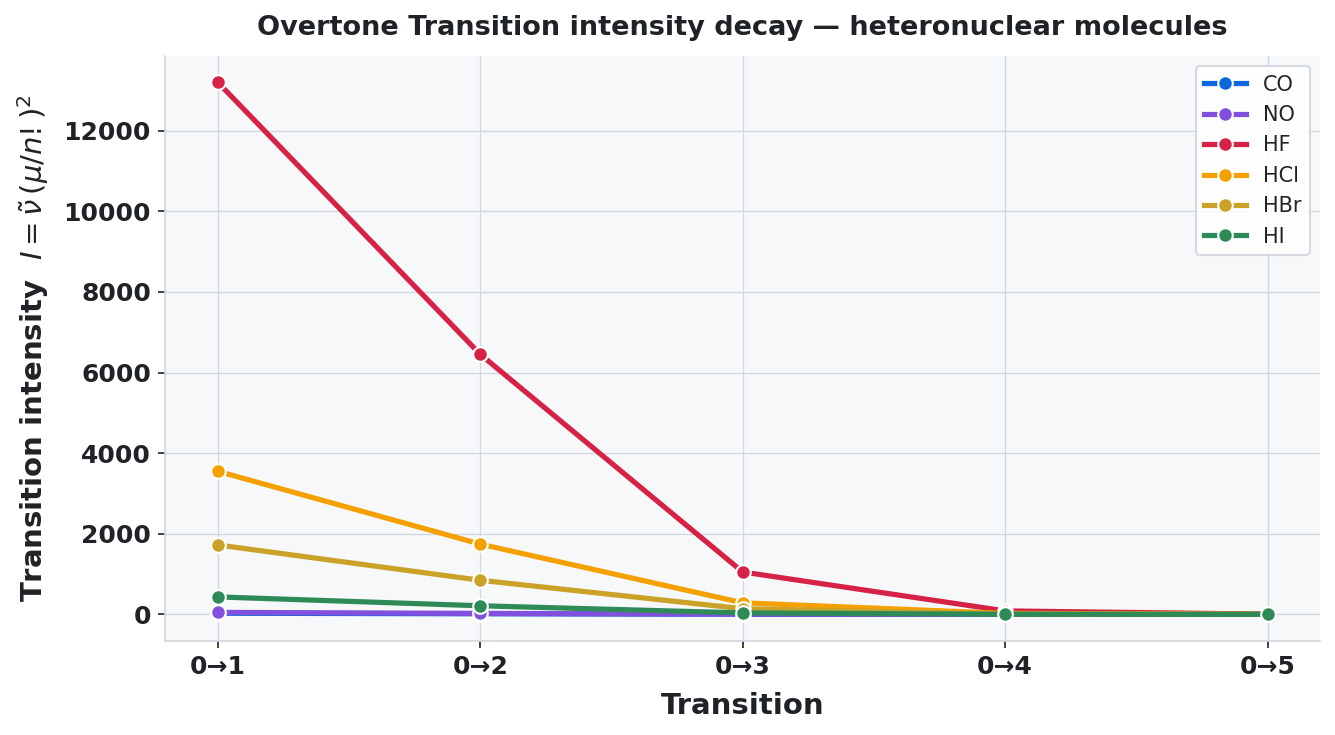

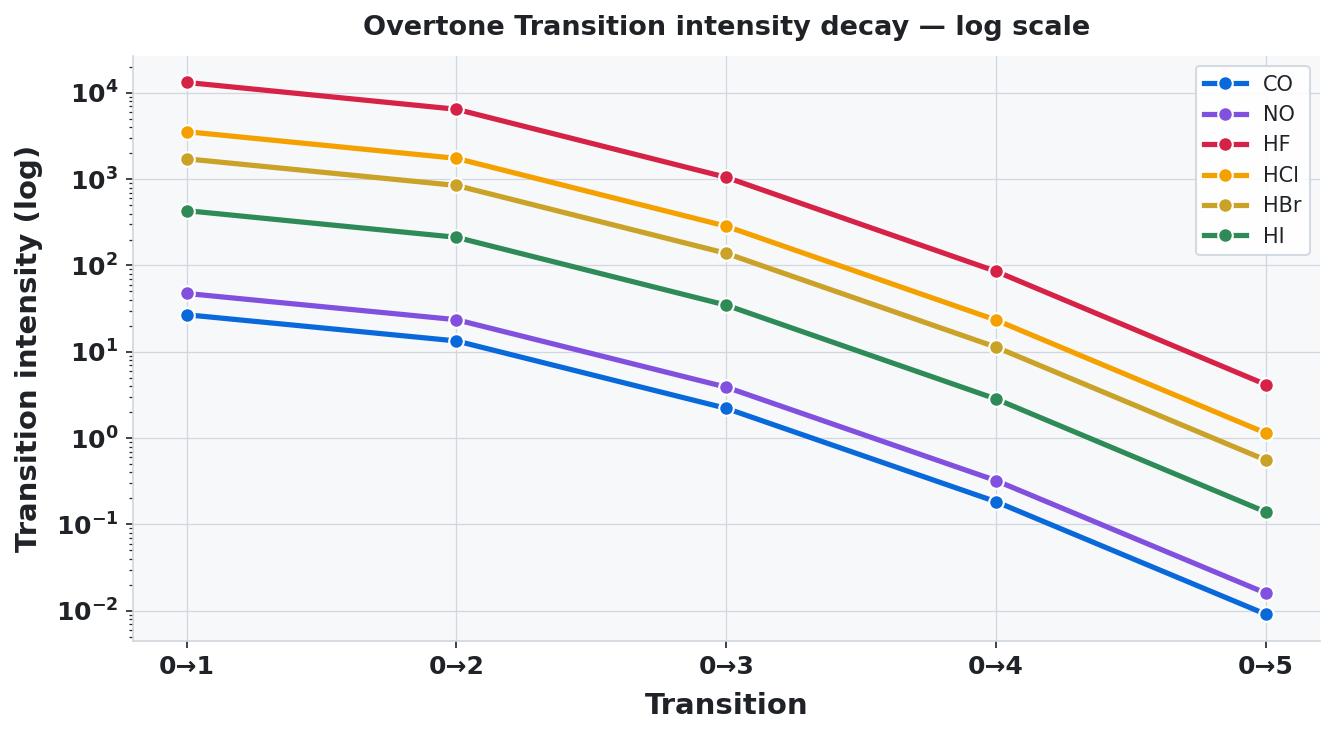

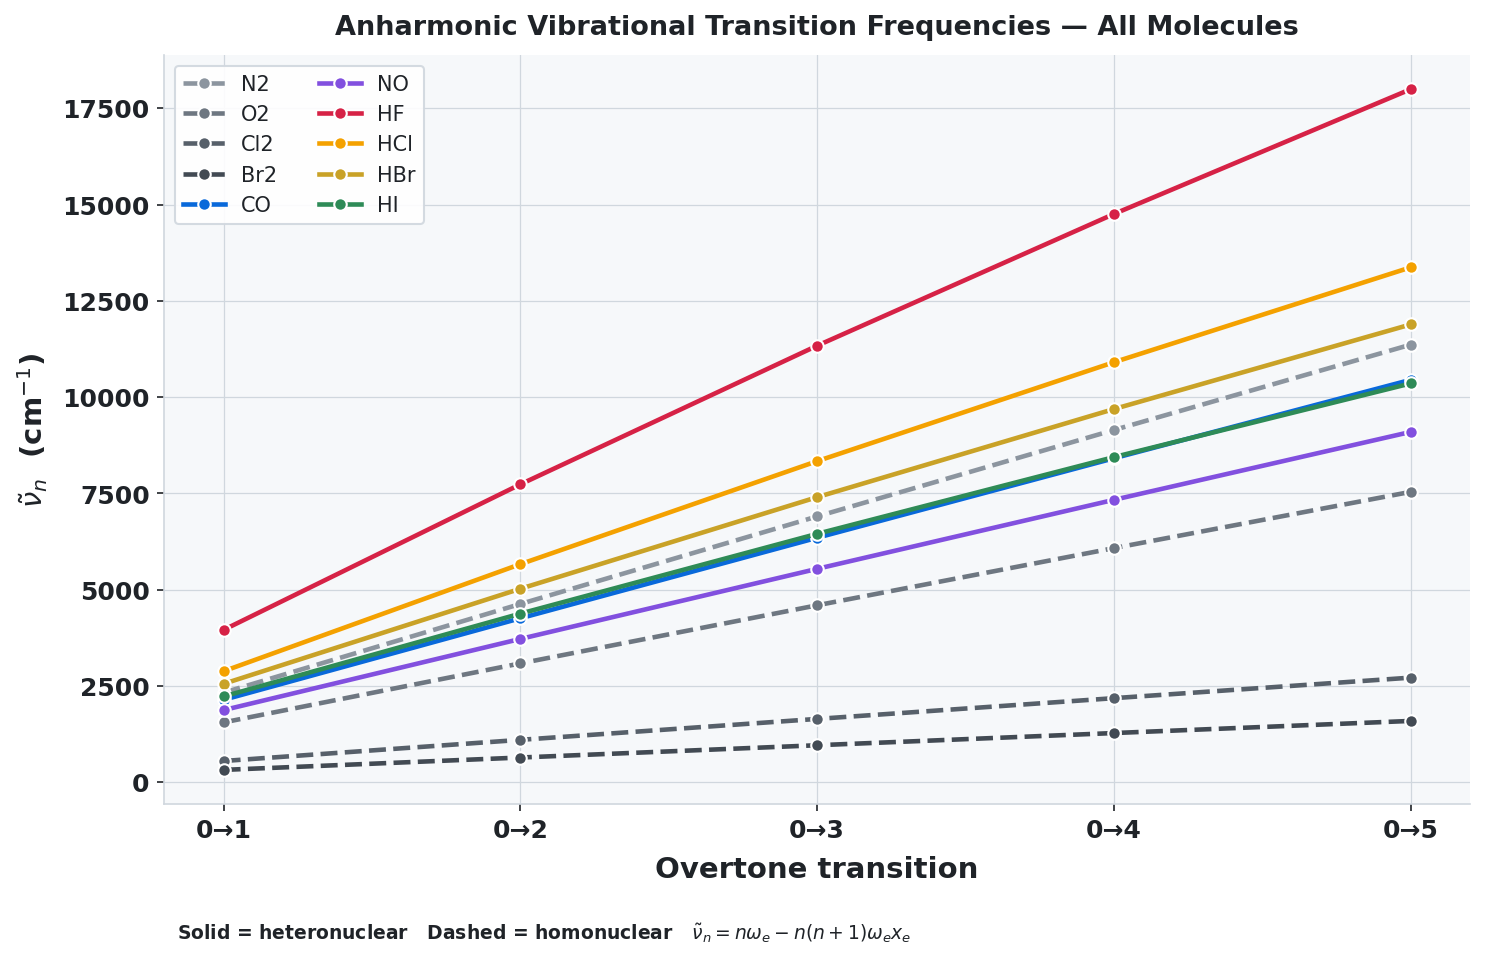

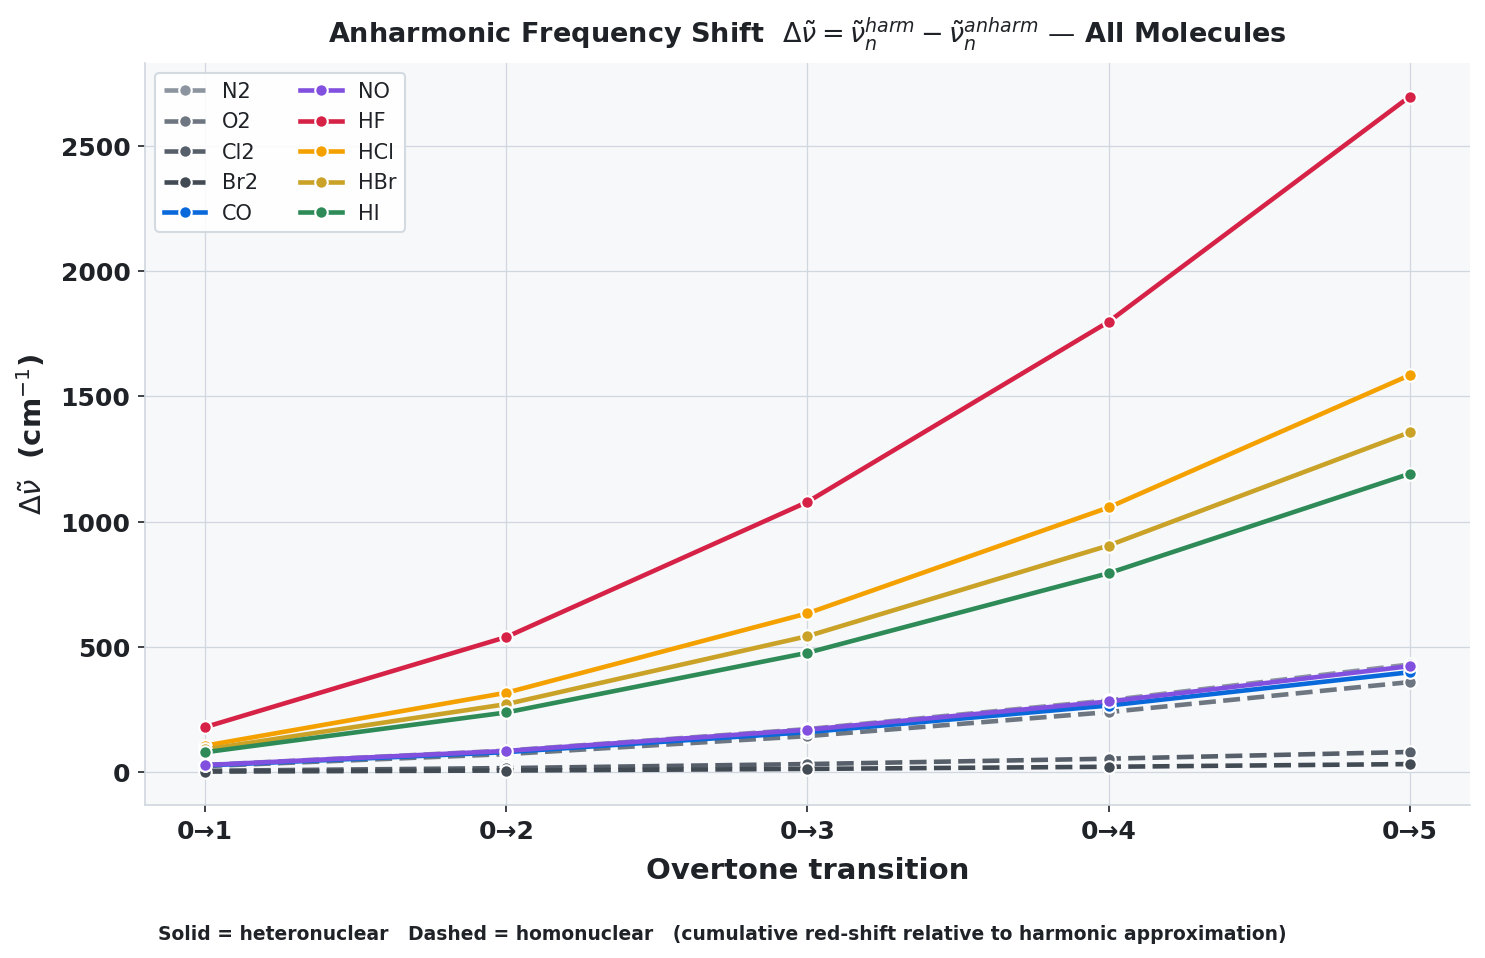

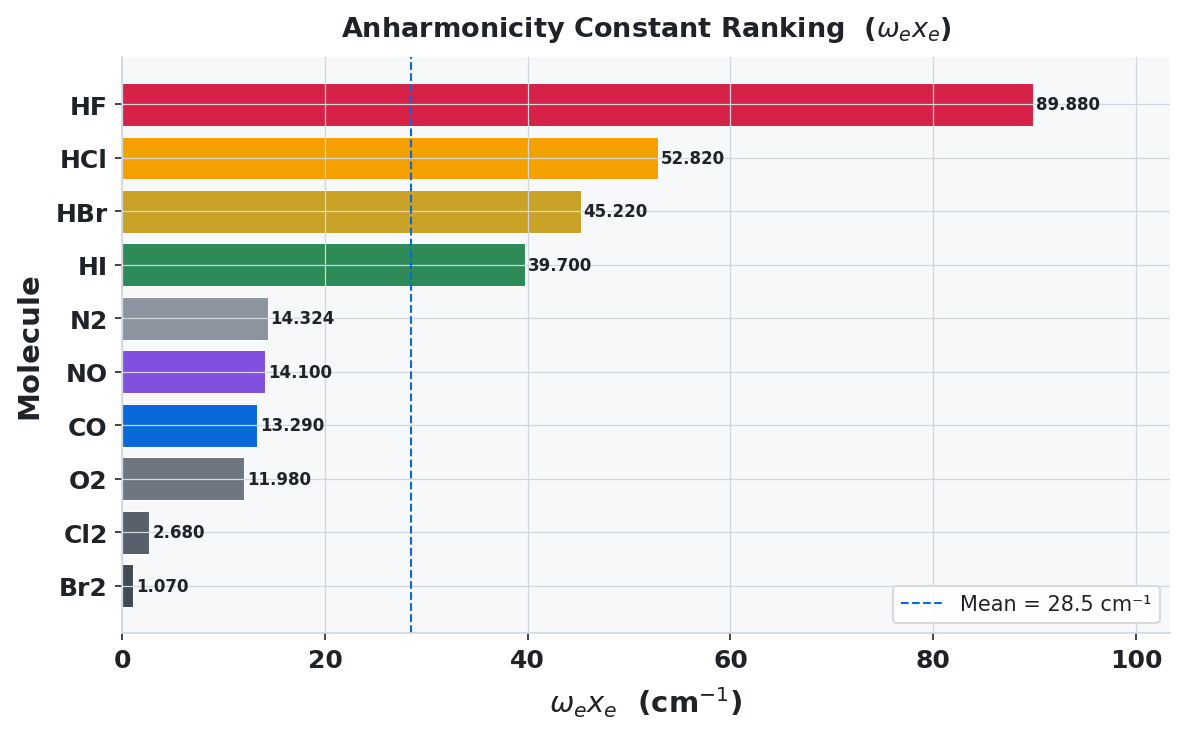

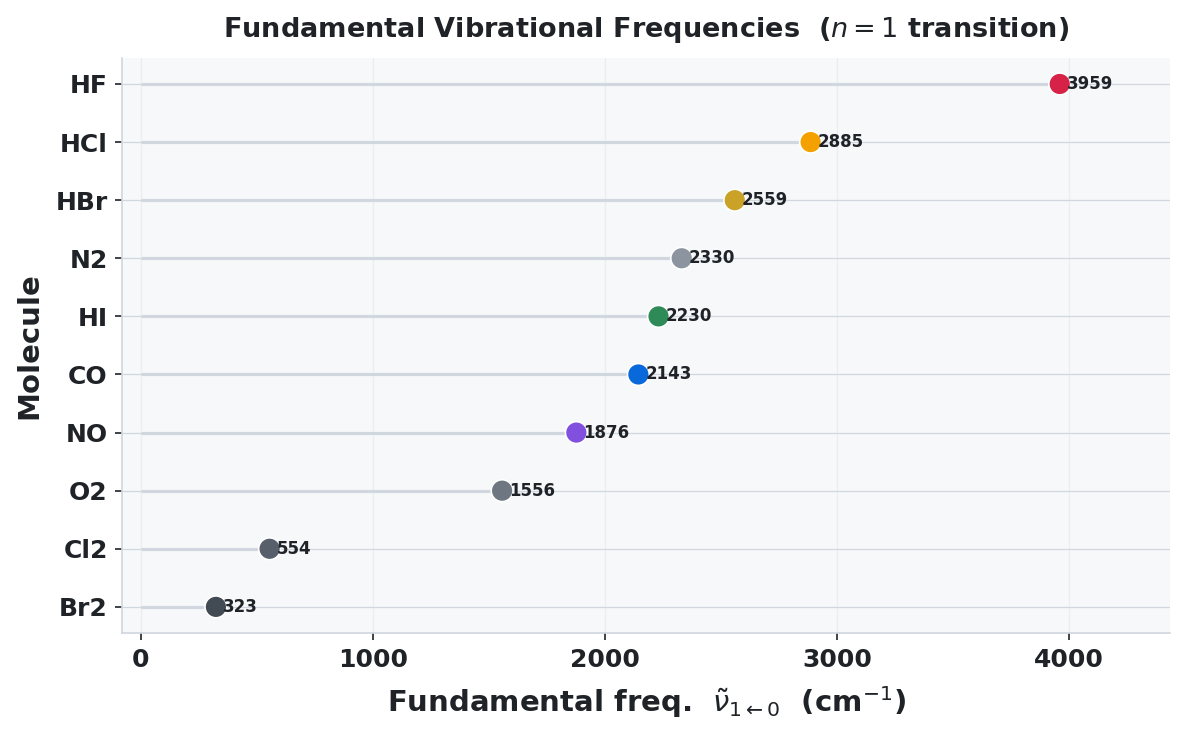

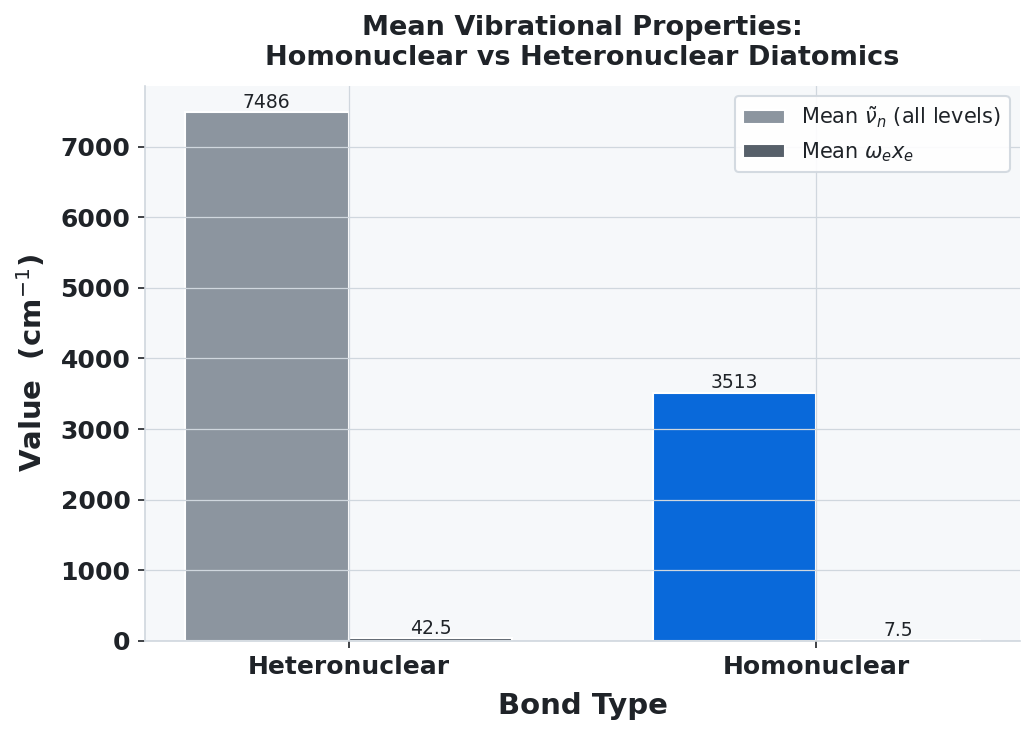

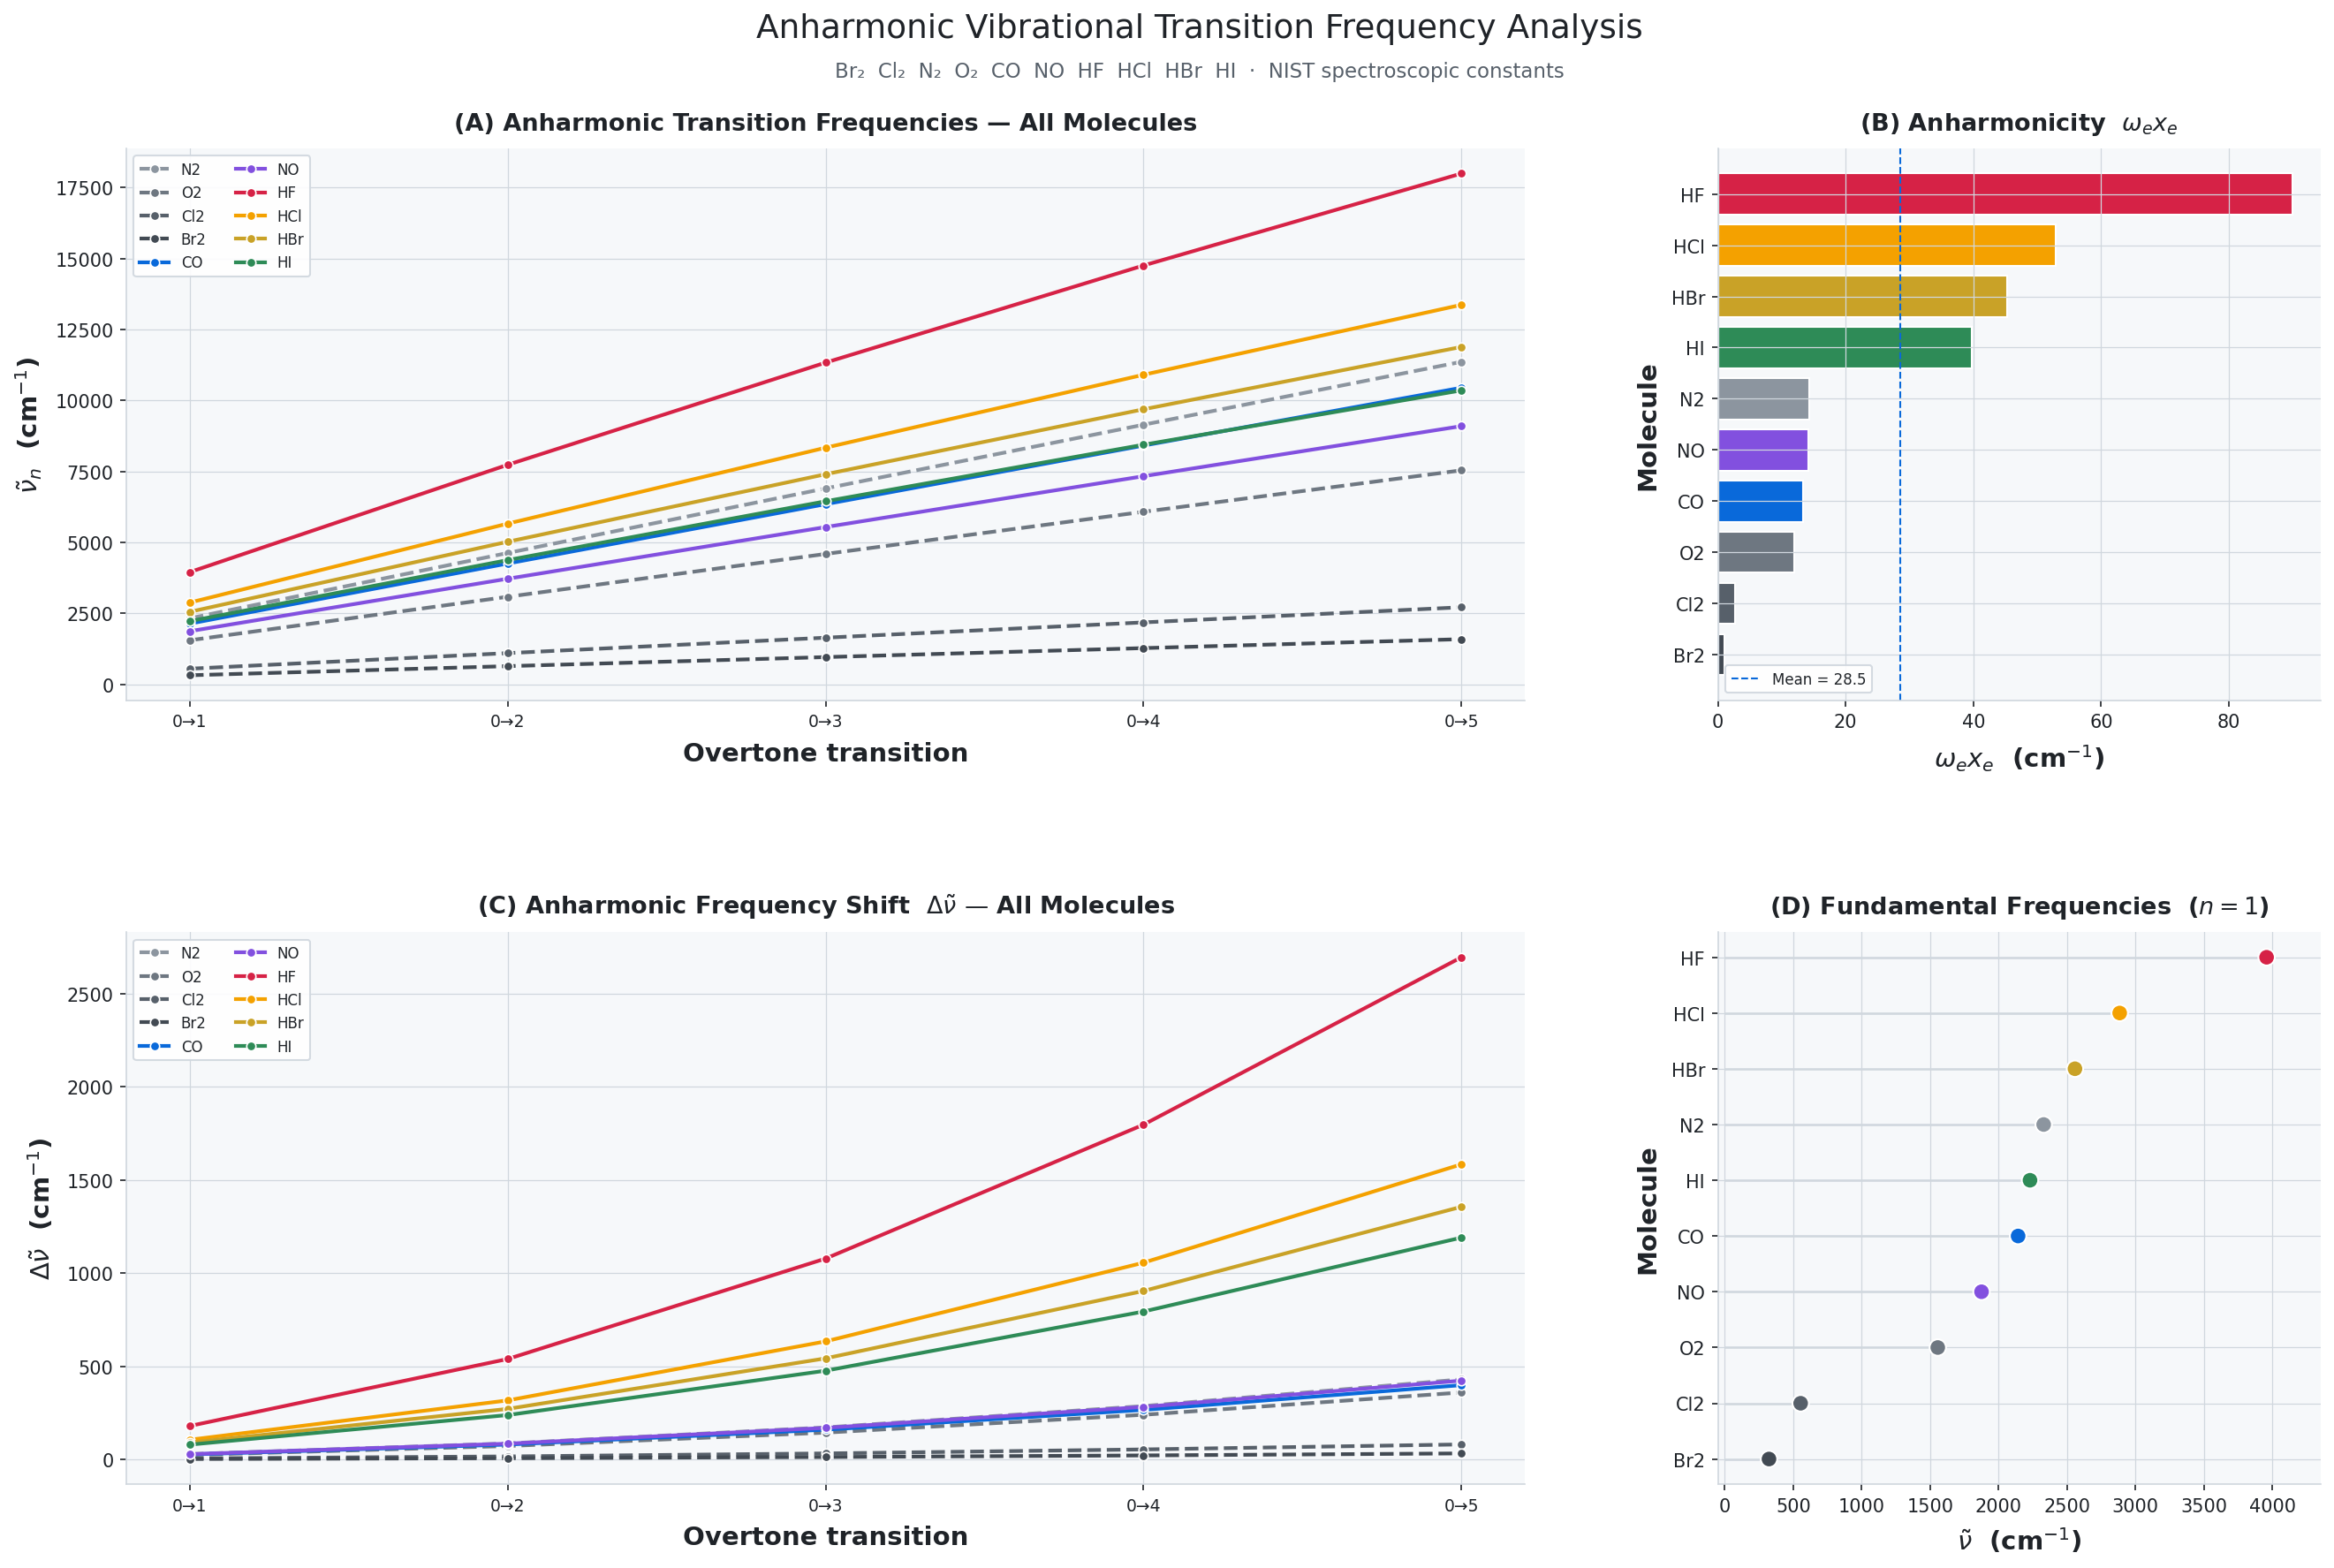


All figures saved.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import LogFormatter
import math

# ==========================================================
# GLOBAL STYLE (light theme)  — defined ONCE
# ==========================================================

BG       = "#FFFFFF"
PANEL_BG = "#F6F8FA"
GRID_CLR = "#D0D7DE"
TEXT_PRI = "#1F2328"
TEXT_SEC = "#57606A"
ACCENT   = "#0969DA"

MOL_COLORS = {
   "HF":  "#D62246",
   "HCl": "#F4A100",
   "HBr": "#C9A227",
   "HI":  "#2E8B57",
   "CO":  "#0969DA",
   "NO":  "#8250DF",
   "N2":  "#8C959F",
   "O2":  "#6E7781",
   "Cl2": "#57606A",
   "Br2": "#424A53",
}

plt.rcParams.update({
   "figure.facecolor":  BG,
   "axes.facecolor":    PANEL_BG,
   "axes.edgecolor":    GRID_CLR,
   "axes.labelcolor":   TEXT_PRI,
   "axes.titlecolor":   TEXT_PRI,
   "axes.titlesize":    13,
   "axes.labelsize":    14,
   "axes.labelweight":  "bold",
   "axes.titleweight":  "bold",
   "axes.grid":         True,
   "axes.spines.top":   False,
   "axes.spines.right": False,
   "grid.color":        GRID_CLR,
   "grid.linewidth":    0.6,
   "xtick.color":       TEXT_PRI,
   "ytick.color":       TEXT_PRI,
   "legend.facecolor":  BG,
   "legend.edgecolor":  GRID_CLR,
   "legend.labelcolor": TEXT_PRI,
   "legend.fontsize":   10,
   "text.color":        TEXT_PRI,
   "font.family":       "DejaVu Sans",
   "figure.dpi":        150,
   "savefig.dpi":       300,
   "savefig.facecolor": BG,
   "savefig.bbox":      "tight",
})

TRANSITION_LABELS = ["0→1", "0→2", "0→3", "0→4", "0→5"]

# ==========================================================
# MOLECULAR CONSTANTS (NIST) — defined ONCE, dipole included
# ==========================================================

molecules = {
   "N2":  {"type": "Homonuclear",   "we": 2358.57, "wexe": 14.324, "dipole": 0.000},
   "O2":  {"type": "Homonuclear",   "we": 1580.19, "wexe": 11.980, "dipole": 0.000},
   "Cl2": {"type": "Homonuclear",   "we":  559.75, "wexe":  2.680, "dipole": 0.000},
   "Br2": {"type": "Homonuclear",   "we":  325.32, "wexe":  1.070, "dipole": 0.000},
   "CO":  {"type": "Heteronuclear", "we": 2169.81, "wexe": 13.290, "dipole": 0.112},
   "NO":  {"type": "Heteronuclear", "we": 1904.20, "wexe": 14.100, "dipole": 0.159},
   "HF":  {"type": "Heteronuclear", "we": 4138.39, "wexe": 89.880, "dipole": 1.826},
   "HCl": {"type": "Heteronuclear", "we": 2990.95, "wexe": 52.820, "dipole": 1.109},
   "HBr": {"type": "Heteronuclear", "we": 2648.98, "wexe": 45.220, "dipole": 0.820},
   "HI":  {"type": "Heteronuclear", "we": 2309.50, "wexe": 39.700, "dipole": 0.440},
}

# ==========================================================
# PHYSICS — defined ONCE
# ν(0→n)      = n·ωe − n(n+1)·ωexe   (anharmonic)
# ν_harm(0→n) = n·ωe                  (harmonic comparison)
# I           = ν · (μ/n!)²           (raw intensity, unnormalised)
# ==========================================================

def transition_frequency(we, wexe, n):
   return n * we - n * (n + 1) * wexe

def harmonic_frequency(we, n):
   return n * we

def tran_intensity(freq, dipole, n):
   if dipole == 0:
       return 0.0
   M = dipole / math.factorial(n)
   return freq * M ** 2

# ==========================================================
# HELPER — defined ONCE
# ==========================================================

def style_ax(ax, title="", xlabel="", ylabel=""):
   ax.set_facecolor(PANEL_BG)
   ax.set_title(title, pad=10)
   ax.set_xlabel(xlabel, labelpad=6)
   ax.set_ylabel(ylabel, labelpad=6)
   for spine in ax.spines.values():
       spine.set_edgecolor(GRID_CLR)

# ==========================================================
# COMPUTE MASTER DATA TABLE  — built ONCE, used everywhere
# Columns: Molecule, Type, Transition, n,
#          Frequency_cm1, Harmonic_cm1, Shift_cm1,
#          wexe, Dipole_D, Raw_Intensity
# ==========================================================

records = []
for mol, d in molecules.items():
   for n in range(1, 6):
       freq  = transition_frequency(d["we"], d["wexe"], n)
       harm  = harmonic_frequency(d["we"], n)
       inten = tran_intensity(freq, d["dipole"], n)
       records.append({
           "Molecule":        mol,
           "Type":            d["type"],
           "Transition":      f"0→{n}",
           "n":               n,
           "Frequency_cm1":   round(freq, 2),
           "Shift_cm1":       round(harm - freq, 2),
           "wexe":            d["wexe"],
           "Dipole_D":        d["dipole"],
           "Tran_Intensity":   inten,
       })

df = pd.DataFrame(records)
df.to_csv("transition_results.csv", index=False)
print(df.to_string(index=False))

# Derived sub-frames used across figures
hetero_mols = [m for m in molecules if molecules[m]["type"] == "Heteronuclear"]
hetero_df   = df[df["Type"] == "Heteronuclear"]
freq_df     = df[df["n"] == 1].sort_values("Frequency_cm1")
anh         = df.groupby("Molecule")["wexe"].first().sort_values()

# ==========================================================
# FIG A — RAW INTENSITY OVERTONE DECAY (linear)
# ==========================================================

fig, ax = plt.subplots(figsize=(9, 5))
style_ax(ax, "Overtone Transition intensity decay — heteronuclear molecules",
        "Transition", r"Transition intensity  $I = \tilde{\nu}\,(\mu/n!)^2$")

for mol in hetero_mols:
   sub = hetero_df[hetero_df["Molecule"] == mol]
   ax.plot(sub["n"], sub["Tran_Intensity"],
           marker="o", lw=2.5, ms=7,
           color=MOL_COLORS[mol], label=mol,
           markeredgecolor=BG, markeredgewidth=1)

ax.set_xticks(range(1, 6))
ax.set_xticklabels(TRANSITION_LABELS)
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig("figA_overtone_decay_linear.png")
plt.show()

# ==========================================================
# FIG B — RAW INTENSITY OVERTONE DECAY (log scale)
# ==========================================================

fig, ax = plt.subplots(figsize=(9, 5))
style_ax(ax, "Overtone Transition intensity decay — log scale",
        "Transition", r"Transition intensity (log)")
for mol in hetero_mols:
   sub = hetero_df[hetero_df["Molecule"] == mol]
   sub = sub[sub["Tran_Intensity"] > 0]
   ax.semilogy(sub["n"], sub["Tran_Intensity"],
               marker="o", lw=2.5, ms=7,
               color=MOL_COLORS[mol], label=mol,
               markeredgecolor=BG, markeredgewidth=1)
ax.set_xticks(range(1, 6))
ax.set_xticklabels(TRANSITION_LABELS)
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
ax.yaxis.set_minor_formatter(LogFormatter(minor_thresholds=(2, 0.4)))
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig("figB_overtone_decay_log.png")
plt.show()
# ==========================================================
# FIG 1 — COMBINED ANHARMONIC TRANSITION FREQUENCIES
# ==========================================================
fig, ax = plt.subplots(figsize=(10, 6.5))
style_ax(ax,
        "Anharmonic Vibrational Transition Frequencies — All Molecules",
        "Overtone transition", r"$\tilde{\nu}_n$  (cm$^{-1}$)")

for mol, d in molecules.items():
   sub = df[df["Molecule"] == mol]
   ls = "-" if d["type"] == "Heteronuclear" else "--"
   ax.plot(sub["n"], sub["Frequency_cm1"],
           marker="o", lw=2.2, ms=6, ls=ls,
           color=MOL_COLORS[mol], label=mol,
           markeredgecolor=BG, markeredgewidth=1)
ax.set_xticks(range(1, 6))
ax.set_xticklabels(TRANSITION_LABELS)
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
ax.legend(framealpha=0.9, ncol=2)
ax.text(0.01, -0.18,
       "Solid = heteronuclear   Dashed = homonuclear   "
       r"$\tilde{\nu}_n = n\omega_e - n(n+1)\omega_e x_e$",
       transform=ax.transAxes, fontsize=9, fontweight='bold', color=TEXT_PRI)
plt.tight_layout()
plt.savefig("fig1_combined_anharmonic_transitions.png")
plt.show()
# ==========================================================
# FIG 2 — COMBINED ANHARMONIC FREQUENCY SHIFT
# ==========================================================
fig, ax = plt.subplots(figsize=(10, 6.5))
style_ax(ax,
        r"Anharmonic Frequency Shift  $\Delta\tilde{\nu} = \tilde{\nu}^{harm}_n - \tilde{\nu}^{anharm}_n$ — All Molecules",
        "Overtone transition", r"$\Delta\tilde{\nu}$  (cm$^{-1}$)")
for mol, d in molecules.items():
   sub = df[df["Molecule"] == mol]
   ls = "-" if d["type"] == "Heteronuclear" else "--"
   ax.plot(sub["n"], sub["Shift_cm1"],
           marker="o", lw=2.2, ms=6, ls=ls,
           color=MOL_COLORS[mol], label=mol,
           markeredgecolor=BG, markeredgewidth=1)
ax.set_xticks(range(1, 6))
ax.set_xticklabels(TRANSITION_LABELS)
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
ax.legend(framealpha=0.9, ncol=2)
ax.text(0.01, -0.18,
       "Solid = heteronuclear   Dashed = homonuclear   "
       "(cumulative red-shift relative to harmonic approximation)",
       transform=ax.transAxes, fontsize=9, fontweight='bold', color=TEXT_PRI)
plt.tight_layout()
plt.savefig("fig2_combined_frequency_shift.png")
plt.show()
# ==========================================================
# FIG 3 — ANHARMONICITY CONSTANT RANKING
# ==========================================================
fig, ax = plt.subplots(figsize=(8, 5))
style_ax(ax, r"Anharmonicity Constant Ranking  ($\omega_e x_e$)",
        r"$\omega_e x_e$  (cm$^{-1}$)", "Molecule")

bars = ax.barh(anh.index, anh.values,
              color=[MOL_COLORS[m] for m in anh.index],
              edgecolor=BG, linewidth=0.5)
for bar, val in zip(bars, anh.values):
   ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
           f"{val:.3f}", va="center", ha="left", fontsize=8, fontweight='bold', color=TEXT_PRI)
ax.axvline(anh.mean(), color=ACCENT, ls="--", lw=1,
          label=f"Mean = {anh.mean():.1f} cm⁻¹")
ax.set_xlim(0, anh.max() * 1.15)
ax.legend(framealpha=0.9)
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig("fig3_anharmonicity_ranking.png")
plt.show()
# ==========================================================
# FIG 4 — FUNDAMENTAL FREQUENCIES (n=1) LOLLIPOP
# ==========================================================
fig, ax = plt.subplots(figsize=(8, 5))
style_ax(ax,
        r"Fundamental Vibrational Frequencies  ($n = 1$ transition)",
        r"Fundamental freq.  $\tilde{\nu}_{1\leftarrow0}$  (cm$^{-1}$)", "Molecule")
ax.hlines(freq_df["Molecule"], 0, freq_df["Frequency_cm1"],
         color=GRID_CLR, lw=1.5, zorder=1)
ax.scatter(freq_df["Frequency_cm1"], freq_df["Molecule"],
          c=[MOL_COLORS[m] for m in freq_df["Molecule"]],
          s=110, zorder=2, edgecolors=BG, linewidths=0.8)
for _, row in freq_df.iterrows():
   ax.text(row["Frequency_cm1"] + 30, row["Molecule"],
           f"{row['Frequency_cm1']:.0f}", va="center", fontsize=8, fontweight='bold', color=TEXT_PRI)
ax.set_xlim(-80, freq_df["Frequency_cm1"].max() * 1.12)
ax.grid(axis="x", alpha=0.3)
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig("fig4_fundamental_frequencies.png")
plt.show()
# ==========================================================
# FIG 5 — HOMONUCLEAR vs HETERONUCLEAR COMPARISON BAR
# ==========================================================
comp = df.groupby("Type").agg(
   Mean_Freq=("Frequency_cm1", "mean"),
   Mean_wexe=("wexe", "mean"),
).reset_index()
fig, ax = plt.subplots(figsize=(7, 5))
style_ax(ax, "Mean Vibrational Properties:\nHomonuclear vs Heteronuclear Diatomics",
        "Bond Type", r"Value  (cm$^{-1}$)")
x  = np.arange(len(comp))
w  = 0.35
c1 = [MOL_COLORS["N2"],  MOL_COLORS["CO"]]
c2 = [MOL_COLORS["Cl2"], MOL_COLORS["HCl"]]
bars1 = ax.bar(x - w / 2, comp["Mean_Freq"], w,
              label=r"Mean $\tilde{\nu}_{n}$ (all levels)",
              color=c1, edgecolor=BG)
bars2 = ax.bar(x + w / 2, comp["Mean_wexe"], w,
              label=r"Mean $\omega_e x_e$",
              color=c2, edgecolor=BG)
for bar in bars1:
   ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
           f"{bar.get_height():.0f}", ha="center", va="bottom",
           fontsize=9, color=TEXT_PRI)
for bar in bars2:
   ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
           f"{bar.get_height():.1f}", ha="center", va="bottom",
           fontsize=9, color=TEXT_PRI)
ax.set_xticks(x)
ax.set_xticklabels(comp["Type"], fontsize=11)
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig("fig5_homo_vs_hetero.png")
plt.show()
# ==========================================================
# MASTER DASHBOARD  (2 × 2 + summary)
# ==========================================================
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor(BG)

fig.text(0.5, 0.98,
        "Anharmonic Vibrational Transition Frequency Analysis",
        ha="center", fontsize=18, color=TEXT_PRI)
fig.text(0.5, 0.955,
        "Br₂  Cl₂  N₂  O₂  CO  NO  HF  HCl  HBr  HI  ·  NIST spectroscopic constants",
        ha="center", fontsize=11, color=TEXT_SEC)

gs = gridspec.GridSpec(2, 3, figure=fig,
                      hspace=0.42, wspace=0.32,
                      left=0.05, right=0.97,
                      top=0.91, bottom=0.07)

# Panel A: combined anharmonic transitions
ax_a = fig.add_subplot(gs[0, :2])
style_ax(ax_a, "(A) Anharmonic Transition Frequencies — All Molecules",
        "Overtone transition", r"$\tilde{\nu}_n$  (cm$^{-1}$)")
for mol, d in molecules.items():
   sub = df[df["Molecule"] == mol]
   ls = "-" if d["type"] == "Heteronuclear" else "--"
   ax_a.plot(sub["n"], sub["Frequency_cm1"], marker="o", lw=2, ms=5,
             ls=ls, color=MOL_COLORS[mol], label=mol,
             markeredgecolor=BG, markeredgewidth=0.8)
ax_a.set_xticks(range(1, 6))
ax_a.set_xticklabels(TRANSITION_LABELS, fontsize=9)
ax_a.legend(fontsize=8, ncol=2, framealpha=0.9)

# Panel B: anharmonicity ranking
ax_b = fig.add_subplot(gs[0, 2])
style_ax(ax_b, r"(B) Anharmonicity  $\omega_e x_e$",
        r"$\omega_e x_e$  (cm$^{-1}$)", "Molecule")
ax_b.barh(anh.index, anh.values,
         color=[MOL_COLORS[m] for m in anh.index], edgecolor=BG)
ax_b.axvline(anh.mean(), color=ACCENT, ls="--", lw=1,
            label=f"Mean = {anh.mean():.1f}")
ax_b.legend(fontsize=8, framealpha=0.9)

# Panel C: combined frequency shift
ax_c = fig.add_subplot(gs[1, :2])
style_ax(ax_c, r"(C) Anharmonic Frequency Shift  $\Delta\tilde{\nu}$ — All Molecules",
        "Overtone transition", r"$\Delta\tilde{\nu}$  (cm$^{-1}$)")
for mol, d in molecules.items():
   sub = df[df["Molecule"] == mol]
   ls = "-" if d["type"] == "Heteronuclear" else "--"
   ax_c.plot(sub["n"], sub["Shift_cm1"], marker="o", lw=2, ms=5,
             ls=ls, color=MOL_COLORS[mol], label=mol,
             markeredgecolor=BG, markeredgewidth=0.8)
ax_c.set_xticks(range(1, 6))
ax_c.set_xticklabels(TRANSITION_LABELS, fontsize=9)
ax_c.legend(fontsize=8, ncol=2, framealpha=0.9)

# Panel D: fundamental frequencies lollipop
ax_d = fig.add_subplot(gs[1, 2])
style_ax(ax_d, r"(D) Fundamental Frequencies  ($n=1$)",
        r"$\tilde{\nu}$  (cm$^{-1}$)", "Molecule")
ax_d.hlines(freq_df["Molecule"], 0, freq_df["Frequency_cm1"],
           color=GRID_CLR, lw=1.2, zorder=1)
ax_d.scatter(freq_df["Frequency_cm1"], freq_df["Molecule"],
            c=[MOL_COLORS[m] for m in freq_df["Molecule"]],
            s=80, zorder=2, edgecolors=BG)
ax_d.set_xlim(-50, freq_df["Frequency_cm1"].max() * 1.1)

plt.savefig("MASTER_DASHBOARD_light.png")
plt.show()

print("\nAll figures saved.")